In [1]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set(style="ticks")


In [4]:
path = r"C:\Users\muthu\Downloads\Online_Retail.csv"
online_rt = pd.read_csv(path, encoding='latin1')
online_rt.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


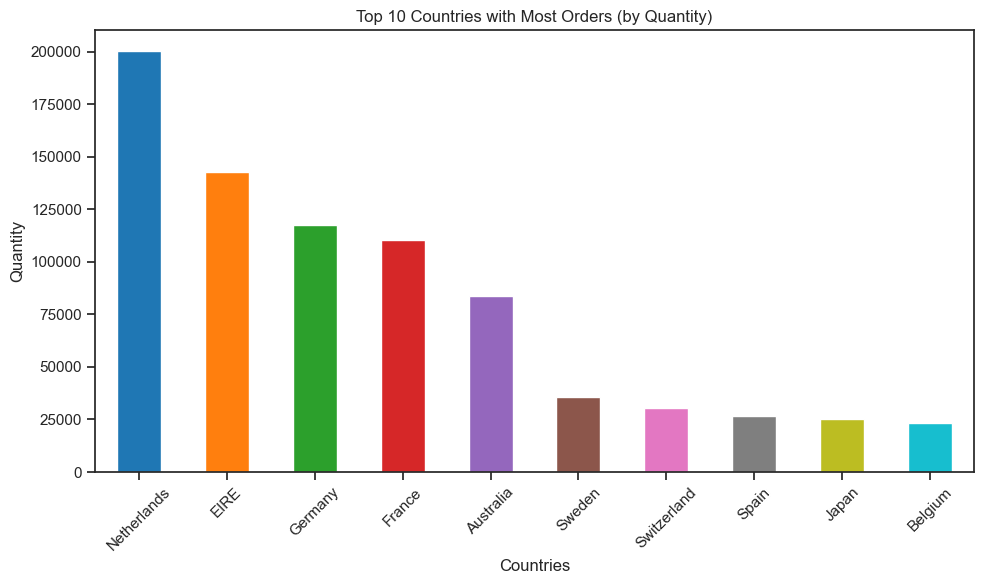

In [5]:
countries = online_rt.groupby("Country").sum(numeric_only=True)
top_countries = countries.sort_values(by="Quantity", ascending=False)[1:11]
colors = plt.cm.tab10.colors  # 10 distinct colors from matplotlib's colormap

# Plotting
top_countries["Quantity"].plot(kind="bar", figsize=(10, 6) , color=colors)
plt.xlabel("Countries")
plt.ylabel("Quantity")
plt.title("Top 10 Countries with Most Orders (by Quantity)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

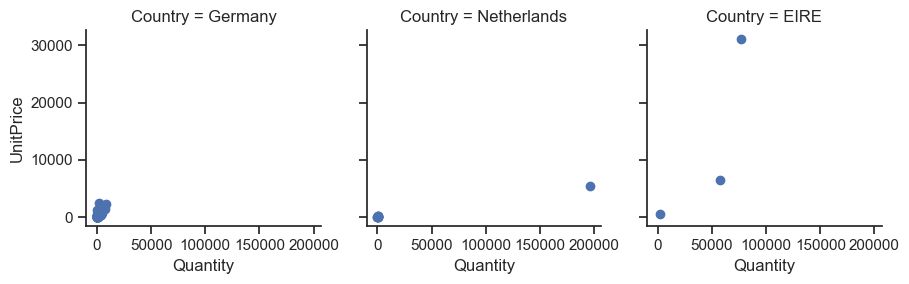

In [12]:
customers = online_rt.groupby(["CustomerID","Country"]).sum()

customers = customers[customers.UnitPrice > 0]

customers["Country"] = customers.index.get_level_values(1)

top_countries = ["Germany", "EIRE", "Netherlands"]

customers = customers[customers['Country'].isin(top_countries)]

g = sns.FacetGrid(customers, col="Country")

g.map(plt.scatter, "Quantity", "UnitPrice", alpha=1)

g.add_legend()

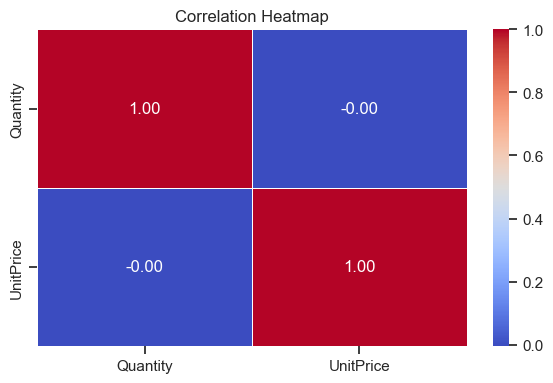

In [13]:
online_rt = pd.read_csv(r"C:\Users\muthu\Downloads\Online_Retail.csv", encoding='latin1')

# Clean data: keep only positive quantities and prices
df = online_rt[(online_rt["Quantity"] > 0) & (online_rt["UnitPrice"] > 0)]

# Select only numeric columns
numeric_df = df[["Quantity", "UnitPrice"]]

# Compute correlation matrix
corr = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [14]:
pip install squarify


  Using cached squarify-0.4.4-py3-none-any.whl.metadata (600 bytes)
Using cached squarify-0.4.4-py3-none-any.whl (4.1 kB)
Note: you may need to restart the kernel to use updated packages.


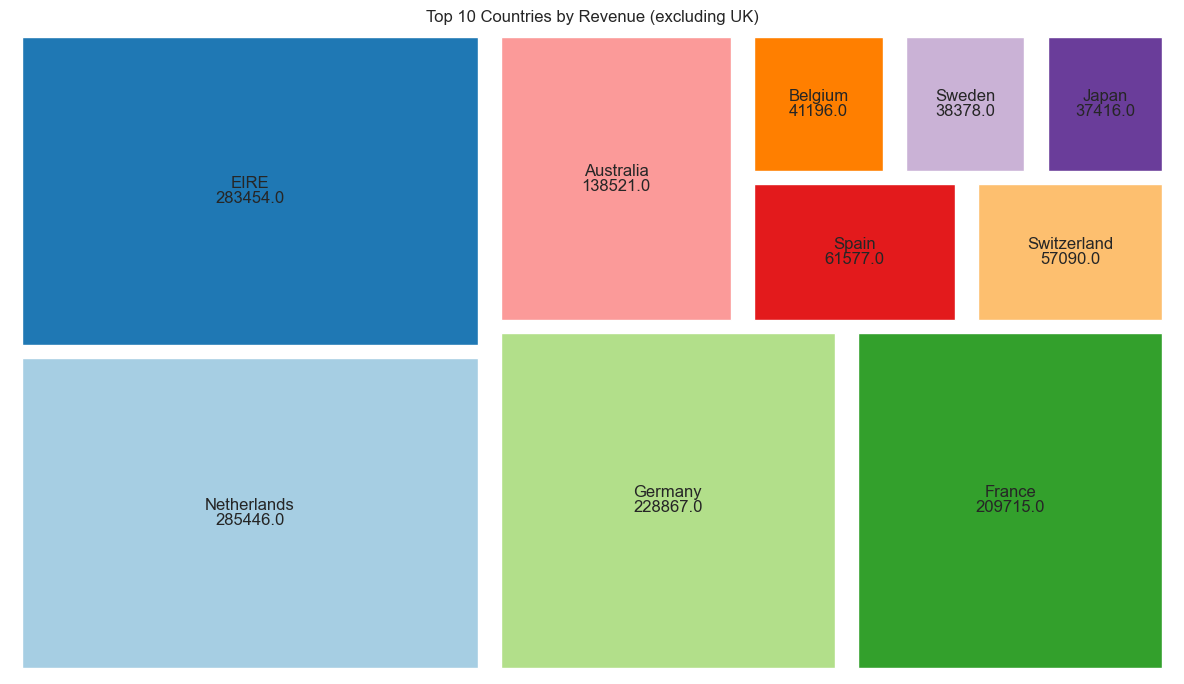

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import squarify  # for treemap

# Load the dataset
df = pd.read_csv(r"C:\Users\muthu\Downloads\Online_Retail.csv", encoding='latin1')

# Clean and compute revenue
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

# Group by country
country_revenue = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False)

# Exclude United Kingdom for clearer view
country_revenue = country_revenue[country_revenue.index != "United Kingdom"]

# Get top 10 countries
top10 = country_revenue.head(10)

# Treemap plot
plt.figure(figsize=(12, 7))
squarify.plot(sizes=top10.values, label=top10.index, value=top10.values.round(0), 
              color=sns.color_palette("Paired", len(top10)), pad=True)
plt.title("Top 10 Countries by Revenue (excluding UK)")
plt.axis("off")
plt.tight_layout()
plt.show()


C:\Users\muthu\AppData\Local\Temp\ipykernel_15348\3084164088.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Country", y="UnitPrice", palette="Set3", inner="box")


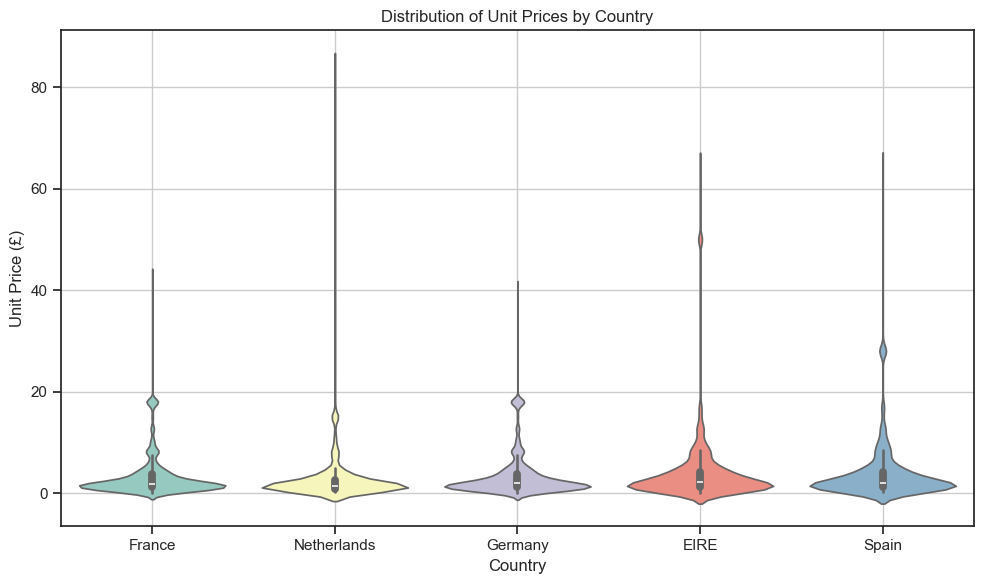

In [18]:
df = pd.read_csv(r"C:\Users\muthu\Downloads\Online_Retail.csv", encoding='latin1')

# Clean the data
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

# Select a few countries
selected_countries = ["Germany", "France", "EIRE", "Spain", "Netherlands"]
df = df[df["Country"].isin(selected_countries)]

# Optional: Cap high unit prices for better scaling
df = df[df["UnitPrice"] < 100]

# Plot
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x="Country", y="UnitPrice", palette="Set3", inner="box")
plt.title("Distribution of Unit Prices by Country")
plt.xlabel("Country")
plt.ylabel("Unit Price (£)")
plt.grid(True)
plt.tight_layout()
plt.show()